In [1]:
import pickle
import os
from matplotlib import pyplot as plt
from typing import Dict

# Import plotting functions from plot_utils
from plot_utils import (
    plot_rmse_comparison_multi,
    plot_rmse_on_axis,
    plot_accuracy_comparison_multi,
    plot_accuracy_on_axis,
)

# BASE_DIR = "/capstor/store/cscs/swissai/infra01/apertus_probes"
BASE_DIR = "/iopsstor/scratch/cscs/astepancic/mera-runs"

In [2]:
def load_pkl(path): 
    with open(path, "rb") as f:
        return pickle.load(f)

def get_paths_for_dataset(dataset_name: str, variant: str = "leave") -> Dict[str, str]:
    """
    Get paths to probe dataframes for both models.

    Args:
        dataset_name: Name of the dataset (e.g., "mmlu_high_school", "ARC-Challenge")
        variant: Either "leave" or "transform"

    Returns:
        dict: Mapping from model name to pickle file path
    """
    filename = f"df_probes_{variant}.pkl"
    paths = {
        "Apertus-8B-Instruct-2509": os.path.join(
            BASE_DIR, dataset_name, "Apertus-8B-Instruct-2509", filename
        ),
        "Llama-3.1-8B-Instruct": os.path.join(
            BASE_DIR, dataset_name, "Llama-3.1-8B-Instruct", filename
        )
    }

    # Validate paths exist
    for model, path in paths.items():
        if not os.path.exists(path):
            print(f"⚠️ Warning: Path does not exist: {path}")
    
    return paths

In [3]:
# All plotting functions are now in plot_utils.py
# Import them at the top of the notebook (cell 0)


In [4]:
# All plotting functions are now in plot_utils.py
# Import them at the top of the notebook (cell 0)


In [5]:
DATASET_NAMES = ["mmlu_high_school", "mmlu_professional", "ARC-Challenge", "ARC-Easy", "sms_spam", "sujet_finance_yesno_5k"]
DATASET_TITLES = ["MMLU High School", "MMLU Professional", "ARC Challenge", "ARC Easy", "SMS Spam", "Finance YesNo"]
MODEL_NAMES = ["Apertus-8B-Instruct-2509", "Llama-3.1-8B-Instruct", "Apertus-8B-2509", "Llama-3.1-8B"]
INDEX = 0

In [6]:
model = MODEL_NAMES[2]


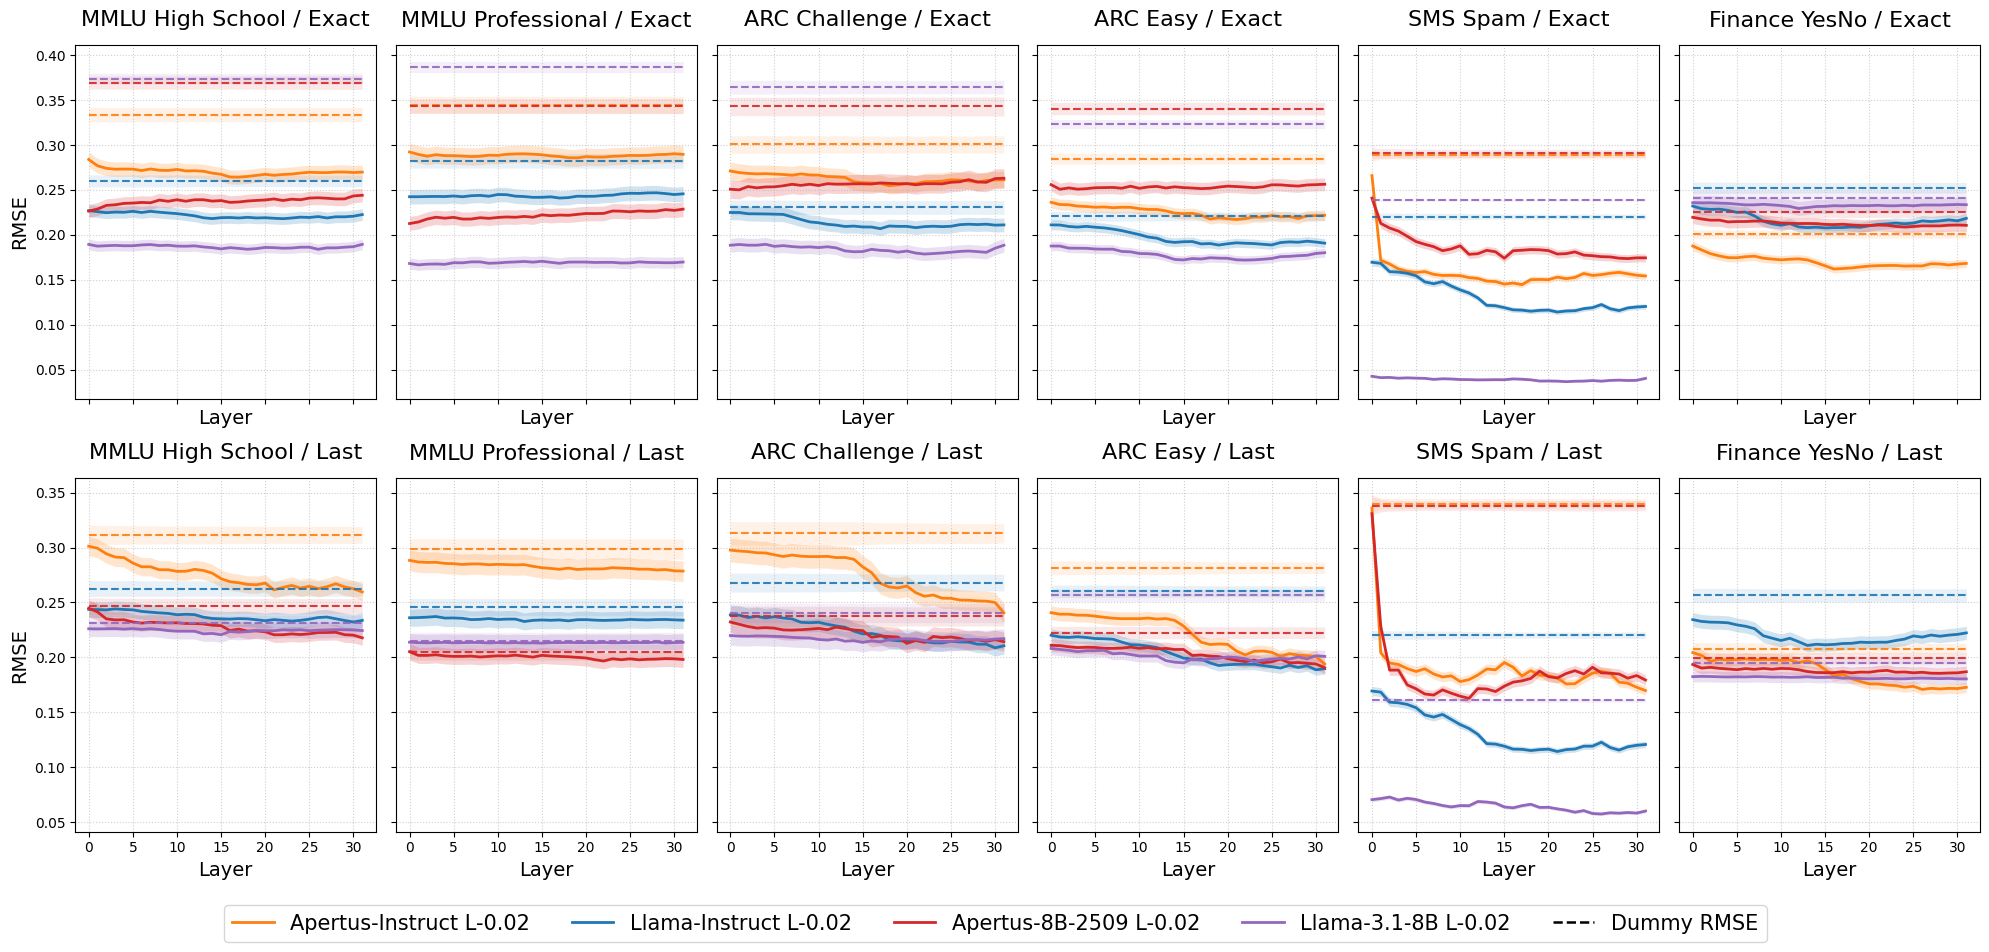

(<Figure size 2000x1000 with 12 Axes>,
 array([[<Axes: title={'center': 'MMLU High School / Exact'}, xlabel='Layer', ylabel='RMSE'>,
         <Axes: title={'center': 'MMLU Professional / Exact'}, xlabel='Layer'>,
         <Axes: title={'center': 'ARC Challenge / Exact'}, xlabel='Layer'>,
         <Axes: title={'center': 'ARC Easy / Exact'}, xlabel='Layer'>,
         <Axes: title={'center': 'SMS Spam / Exact'}, xlabel='Layer'>,
         <Axes: title={'center': 'Finance YesNo / Exact'}, xlabel='Layer'>],
        [<Axes: title={'center': 'MMLU High School / Last'}, xlabel='Layer', ylabel='RMSE'>,
         <Axes: title={'center': 'MMLU Professional / Last'}, xlabel='Layer'>,
         <Axes: title={'center': 'ARC Challenge / Last'}, xlabel='Layer'>,
         <Axes: title={'center': 'ARC Easy / Last'}, xlabel='Layer'>,
         <Axes: title={'center': 'SMS Spam / Last'}, xlabel='Layer'>,
         <Axes: title={'center': 'Finance YesNo / Last'}, xlabel='Layer'>]],
       dtype=object))

In [7]:
def plot_rmse_multi_dataset_multi_model(
    model_indices: list,
    probe_type: str = "logit",
    dataset_indices: list = None,
    models_to_plot: list = None,
    subdir: str = "mix",
    file_suffix: str = "_intercept",
    figsize: tuple = (20, 10),
    sharey: str = "row",
):
    """
    Plot RMSE comparison across multiple datasets and models in a grid layout.
    
    Args:
        model_indices: List of indices into MODEL_NAMES (e.g., [2, 3, 0, 1]) or list of model names
        probe_type: Type of probe ("linear" or "logit")
        dataset_indices: List of indices into DATASET_NAMES (default: all [0, 1, 2, 3, 4])
        models_to_plot: List of probe models to plot (e.g., ["L-0.05", "L-0.1"])
        subdir: Subdirectory in BASE_DIR (default: "mix")
        file_suffix: Suffix for pickle files (default: "_intercept")
        figsize: Figure size tuple (default: (20, 10))
        sharey: Whether to share y-axis ("row", "col", "all", or False)
    
    Returns:
        fig, axes: Matplotlib figure and axes objects
    """
    if dataset_indices is None:
        dataset_indices = [0, 1, 2, 3, 4]
    if models_to_plot is None:
        models_to_plot = ["L-0.05"]
    
    # Convert model indices to model names if needed
    model_names = []
    for idx in model_indices:
        if isinstance(idx, int):
            model_names.append(MODEL_NAMES[idx])
        else:
            model_names.append(idx)  # Assume it's already a model name
    
    # 2 rows (Exact / Last) × N datasets
    fig, axes = plt.subplots(
        2, len(dataset_indices),
        figsize=figsize,
        sharex="col",   # share x within each column
        sharey=sharey   # share y within each row
    )
    
    # Handle single dataset case (axes becomes 1D)
    if len(dataset_indices) == 1:
        axes = axes.reshape(2, 1)
    
    legend_handles, legend_labels = None, None
    
    for col, idx in enumerate(dataset_indices):
        dataset_name = DATASET_NAMES[idx]
        dataset_title = DATASET_TITLES[idx]
        
        # Load data for all models
        results_by_llm = {}
        for model_name in model_names:
            path = f"{BASE_DIR}/{subdir}/{dataset_name}/{model_name}/df_probes_{probe_type}{file_suffix}.pkl"
            if os.path.exists(path):
                results_by_llm[model_name] = load_pkl(path)
            else:
                print(f"⚠️ Warning: Path does not exist: {path}")
        
        if not results_by_llm:
            print(f"⚠️ Warning: No data loaded for dataset {dataset_name}")
            continue
        
        # ---- Row 0: Exact token ----
        handles, labels = plot_rmse_on_axis(
            axes[0, col],
            results_by_llm=results_by_llm,
            models_to_plot=models_to_plot,
            token_positions=["exact"],
            title_suffix=f"{dataset_title} / Exact",
            add_legend=False,
        )

        # ---- Row 1: Last token ----
        plot_rmse_on_axis(
            axes[1, col],
            results_by_llm=results_by_llm,
            models_to_plot=models_to_plot,
            token_positions=["last"],
            title_suffix=f"{dataset_title} / Last",
            add_legend=False,
        )

        # grab legend info from first subplot only
        if legend_handles is None:
            legend_handles, legend_labels = handles, labels

    # Only left column gets y-labels (optional, for cleanliness)
    for row in range(2):
        for col in range(1, len(dataset_indices)):
            axes[row, col].set_ylabel("")

    # One shared legend at the top
    if legend_handles is not None:
        fig.legend(
            legend_handles,
            legend_labels,
            fontsize=15,
            loc="upper center",
            bbox_to_anchor=(0.5, -0.0),
            ncol=len(legend_labels),
            frameon=True,
        )
    # fig.suptitle(f"RMSE Comparison for {probe_type} probes", fontsize=20)
    fig.tight_layout(rect=[0, 0, 1, 0.9])
    plt.show()
    
    return fig, axes


# Example usage:
INDICES = [0, 1, 2, 3, 4, 5]                     # which datasets to use
models_to_plot = ["L-0.02"]

# Plot with 4 models using logit probe type
plot_rmse_multi_dataset_multi_model(
    model_indices=[0, 1, 2, 3],  # MODEL_NAMES[2], MODEL_NAMES[3], MODEL_NAMES[0], MODEL_NAMES[1]
    probe_type="linear",
    dataset_indices=INDICES,
    models_to_plot=models_to_plot,
)


In [8]:
# More usage examples:

# Example 1: Plot with 2 models using linear probe type
# plot_rmse_multi_dataset_multi_model(
#     model_indices=[0, 1],  # Just 2 models
#     probe_type="linear",
#     dataset_indices=[0, 1, 2],  # Only first 3 datasets
#     models_to_plot=["L-0.05", "L-0.1"],
# )

# Example 2: Plot with model names directly (instead of indices)
# plot_rmse_multi_dataset_multi_model(
#     model_indices=["Apertus-8B-2509", "Llama-3.1-8B"],  # Direct model names
#     probe_type="logit",
#     models_to_plot=["L-0.05"],
# )

# Example 3: Plot with different subdirectory and file suffix
# plot_rmse_multi_dataset_multi_model(
#     model_indices=[2],
#     probe_type="logit",
#     subdir="",  # No subdirectory
#     file_suffix="",  # No suffix
#     dataset_indices=[0],  # Single dataset
# )


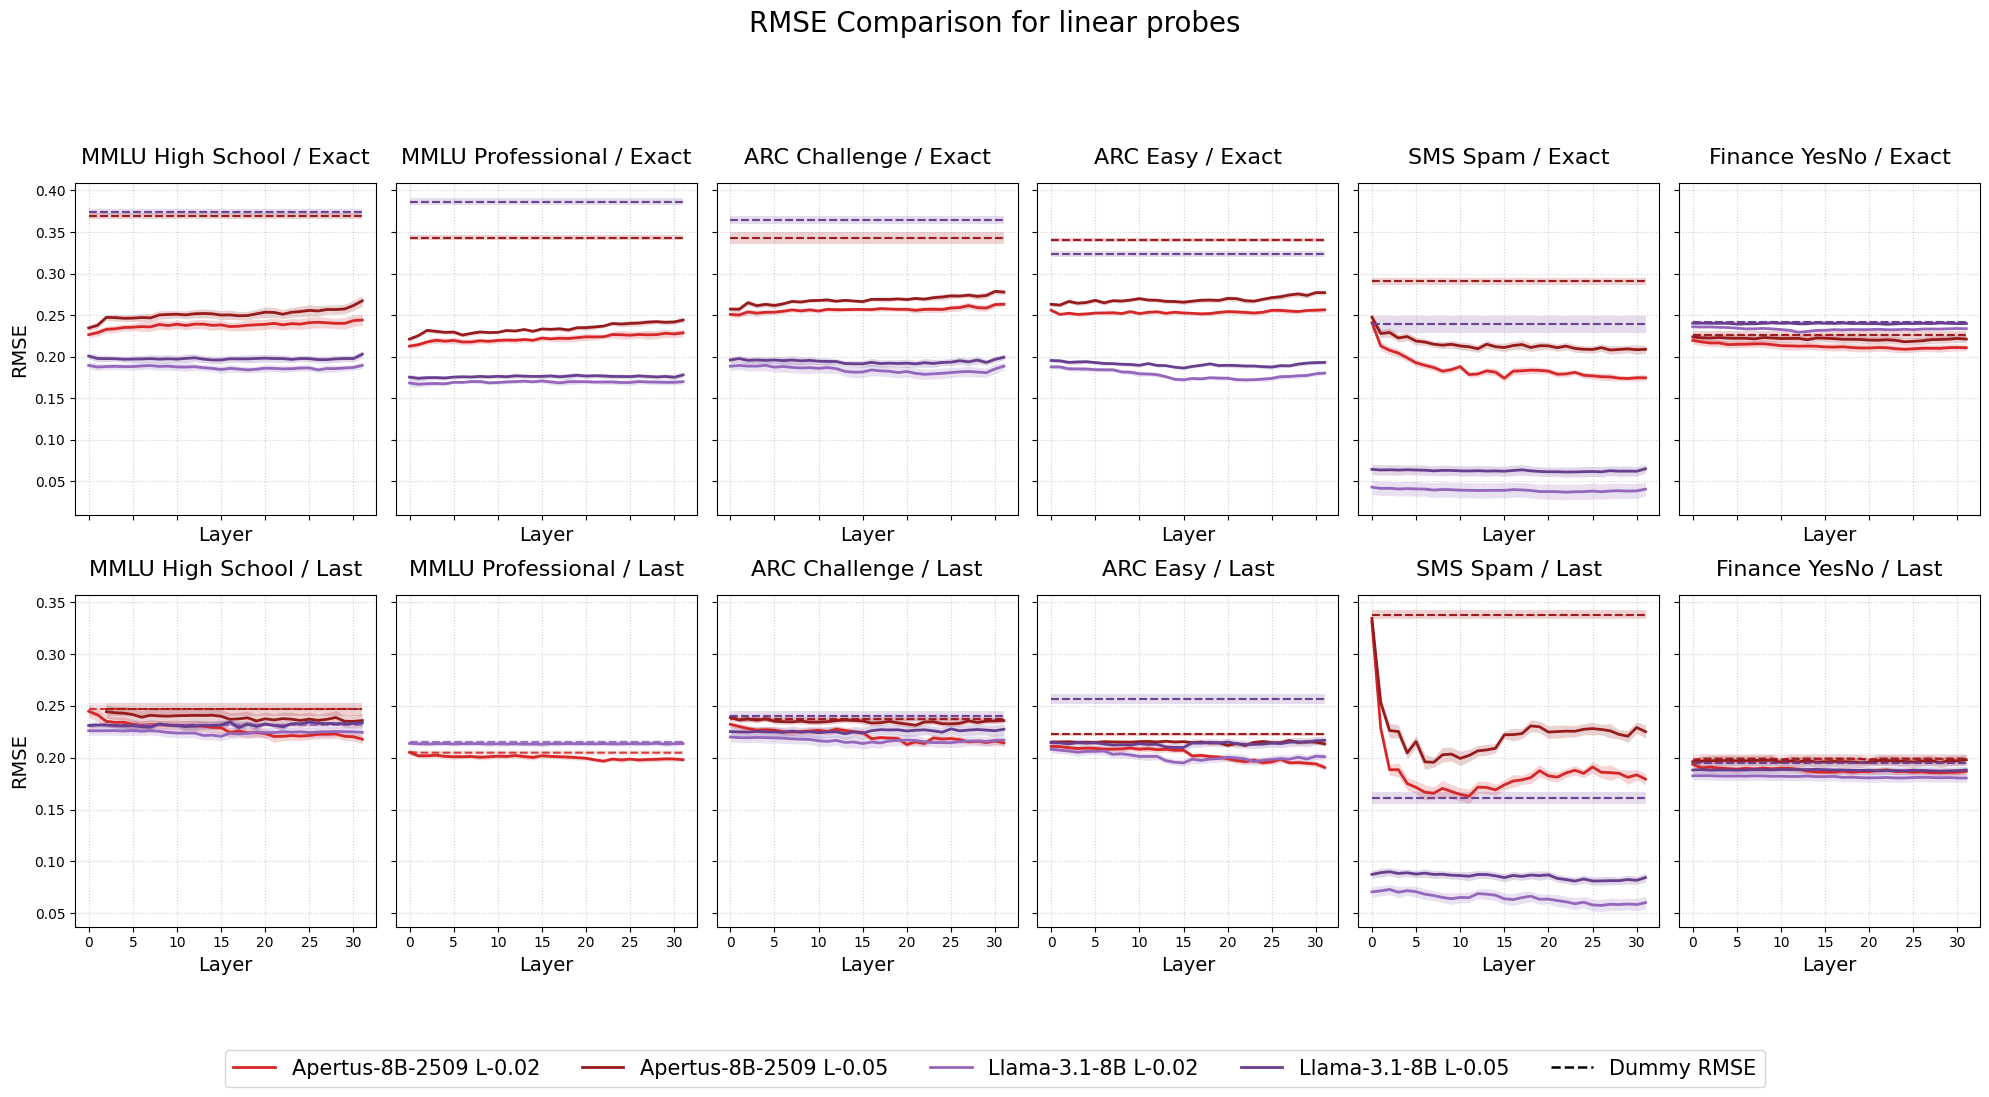

(<Figure size 2000x1000 with 12 Axes>,
 array([[<Axes: title={'center': 'MMLU High School / Exact'}, xlabel='Layer', ylabel='RMSE'>,
         <Axes: title={'center': 'MMLU Professional / Exact'}, xlabel='Layer'>,
         <Axes: title={'center': 'ARC Challenge / Exact'}, xlabel='Layer'>,
         <Axes: title={'center': 'ARC Easy / Exact'}, xlabel='Layer'>,
         <Axes: title={'center': 'SMS Spam / Exact'}, xlabel='Layer'>,
         <Axes: title={'center': 'Finance YesNo / Exact'}, xlabel='Layer'>],
        [<Axes: title={'center': 'MMLU High School / Last'}, xlabel='Layer', ylabel='RMSE'>,
         <Axes: title={'center': 'MMLU Professional / Last'}, xlabel='Layer'>,
         <Axes: title={'center': 'ARC Challenge / Last'}, xlabel='Layer'>,
         <Axes: title={'center': 'ARC Easy / Last'}, xlabel='Layer'>,
         <Axes: title={'center': 'SMS Spam / Last'}, xlabel='Layer'>,
         <Axes: title={'center': 'Finance YesNo / Last'}, xlabel='Layer'>]],
       dtype=object))

In [17]:
plot_rmse_multi_dataset_multi_model(
    model_indices=[2,3],  # MODEL_NAMES[2], MODEL_NAMES[3], MODEL_NAMES[0], MODEL_NAMES[1]
    probe_type="linear",
    dataset_indices=INDICES,
    models_to_plot=models_to_plot,
)

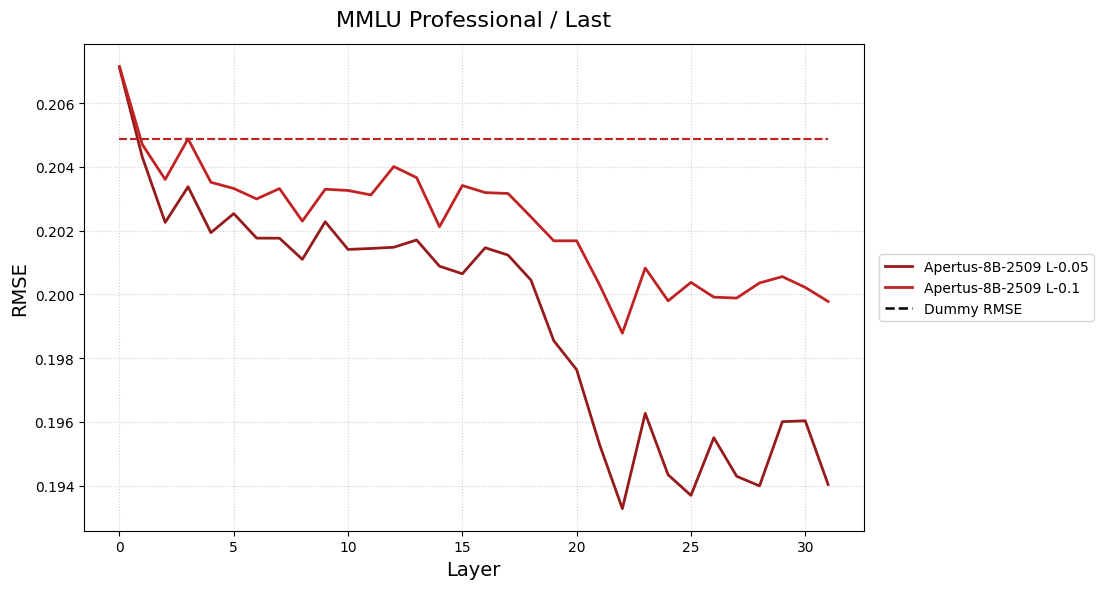

<Axes: title={'center': 'MMLU Professional / Last'}, xlabel='Layer', ylabel='RMSE'>

In [10]:
INDEX=1
dataset_name = DATASET_NAMES[INDEX]
dataset_in_title = DATASET_TITLES[INDEX]
variant = "transform"                   # or "transform"
path = BASE_DIR + f"/mix/{dataset_name}/{MODEL_NAMES[2]}/df_probes_logit_intercept.pkl"
model = MODEL_NAMES[2]
results_by_llm = {model: load_pkl(path)}
models_to_plot = ["L-0.05", "L-0.1"]
# last position
plot_rmse_comparison_multi(
    results_by_llm,
    models_to_plot=models_to_plot,
    token_positions=["last"],
    title_suffix=f"{dataset_in_title} / Last",
)


['LogReg-l1' 'L-0.5' 'L-0.25' 'L-0.1' 'L-0.05' 'L-0']
                        Dataset                 LLM_Model            Task  \
0    sms_spam+mmlu_professional  Apertus-8B-Instruct-2509  classification   
1    sms_spam+mmlu_professional  Apertus-8B-Instruct-2509  classification   
2    sms_spam+mmlu_professional  Apertus-8B-Instruct-2509  classification   
3    sms_spam+mmlu_professional  Apertus-8B-Instruct-2509  classification   
4    sms_spam+mmlu_professional  Apertus-8B-Instruct-2509  classification   
..                          ...                       ...             ...   
955  sms_spam+mmlu_professional  Apertus-8B-Instruct-2509      regression   
956  sms_spam+mmlu_professional  Apertus-8B-Instruct-2509      regression   
957  sms_spam+mmlu_professional  Apertus-8B-Instruct-2509      regression   
958  sms_spam+mmlu_professional  Apertus-8B-Instruct-2509      regression   
959  sms_spam+mmlu_professional  Apertus-8B-Instruct-2509      regression   

         Model  Layer

KeyError: "Columns not found: 'Dummy-RMSE', 'RMSE'"

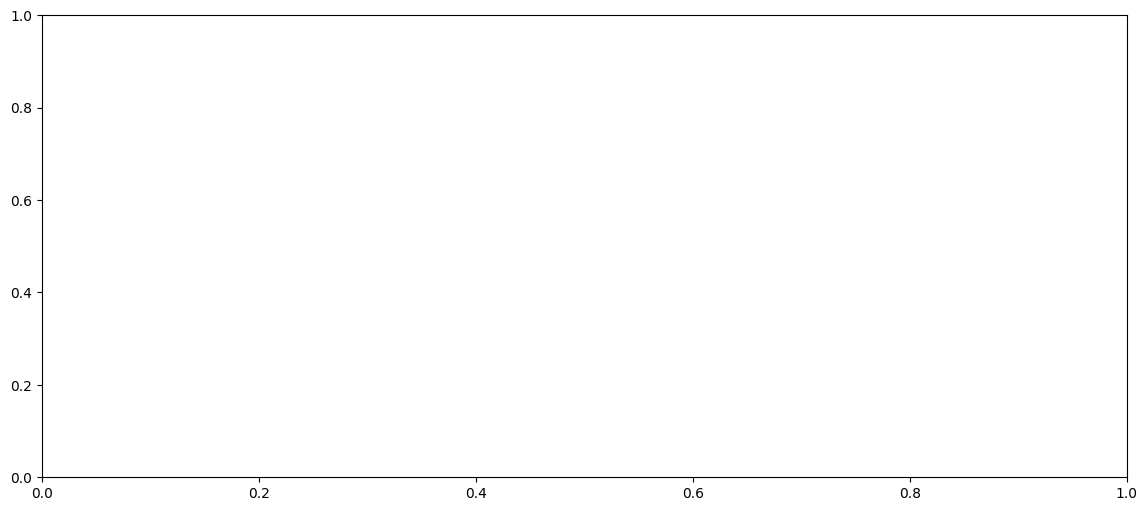

In [11]:
path = BASE_DIR + f"/mix/{MODEL_NAMES[0]}/df_probes_demo.pkl"
df = load_pkl(path)
df.rename(columns={"Probe Model": "Model"}, inplace=True)
llm_model = df["LLM_Model"].unique()[0]
dataset_in_title = df["Dataset"].unique()[0]
models_to_plot = {llm_model: df}
print(df["Model"].unique())

print(df)
plot_rmse_comparison_multi(
    models_to_plot,
    models_to_plot=["L-0.1", "L-0.25"],
    token_positions=["last"],
    title_suffix=f"{dataset_in_title} / {llm_model}",
)


In [ ]:
# last token
plot_rmse_comparison_multi(
    results_by_llm,
    models_to_plot=models_to_plot,
    token_positions=["last"],
    title_suffix=f"{dataset_in_title} / Last",
)

NameError: name 'plot_rmse_comparison_multi' is not defined

['LogReg-l1' 'L-0.02' 'L-0.05']
                                               Dataset  \
0    ARC-Challenge+ARC-Easy+mmlu_high_school+mmlu_p...   
1    ARC-Challenge+ARC-Easy+mmlu_high_school+mmlu_p...   
2    ARC-Challenge+ARC-Easy+mmlu_high_school+mmlu_p...   
3    ARC-Challenge+ARC-Easy+mmlu_high_school+mmlu_p...   
4    ARC-Challenge+ARC-Easy+mmlu_high_school+mmlu_p...   
..                                                 ...   
955  ARC-Challenge+ARC-Easy+mmlu_high_school+mmlu_p...   
956  ARC-Challenge+ARC-Easy+mmlu_high_school+mmlu_p...   
957  ARC-Challenge+ARC-Easy+mmlu_high_school+mmlu_p...   
958  ARC-Challenge+ARC-Easy+mmlu_high_school+mmlu_p...   
959  ARC-Challenge+ARC-Easy+mmlu_high_school+mmlu_p...   

                    LLM_Model            Task      Model  Layer  \
0    Apertus-8B-Instruct-2509  classification  LogReg-l1      0   
1    Apertus-8B-Instruct-2509  classification  LogReg-l1      0   
2    Apertus-8B-Instruct-2509  classification  LogReg-l1      0   
3  

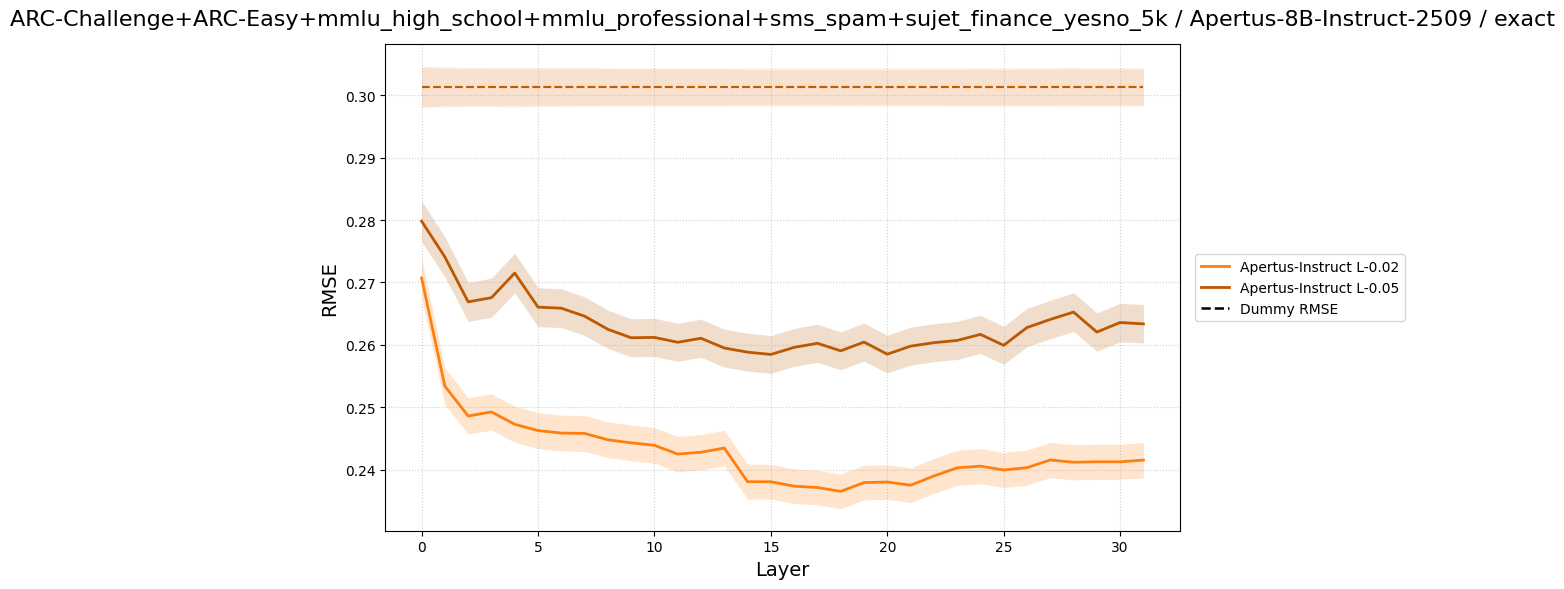

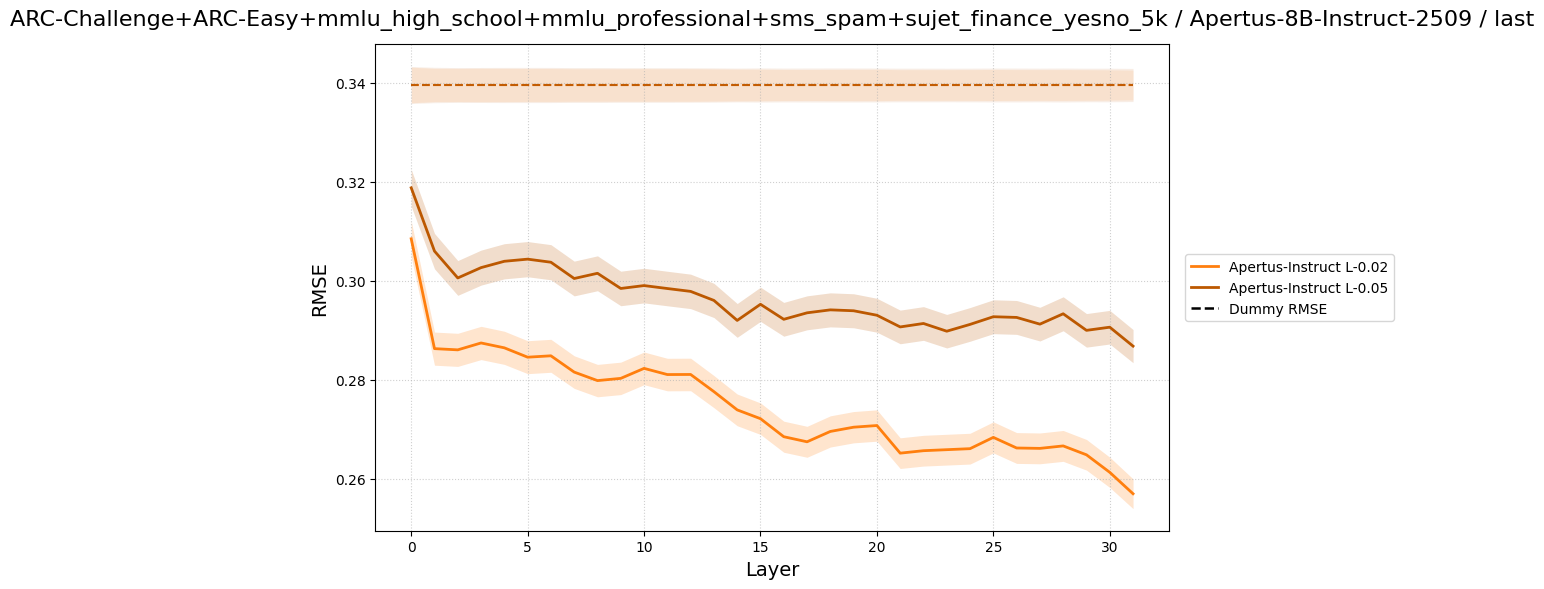

<Axes: title={'center': 'ARC-Challenge+ARC-Easy+mmlu_high_school+mmlu_professional+sms_spam+sujet_finance_yesno_5k / Apertus-8B-Instruct-2509 / last'}, xlabel='Layer', ylabel='RMSE'>

In [12]:
MIX_NAME = "All datasets"
path = f"/iopsstor/scratch/cscs/astepancic/mera-runs/mix/ARC-Challenge+ARC-Easy+mmlu_high_school+mmlu_professional+sms_spam+sujet_finance_yesno_5k/{MODEL_NAMES[0]}/df_probes_linear_intercept.pkl"

df = load_pkl(path)
llm_model = df["LLM_Model"].unique()[0]
dataset_in_title = df["Dataset"].unique()[0]
models_to_plot = {llm_model: df}
print(df["Model"].unique())

print(df)
plot_rmse_comparison_multi(
    models_to_plot,
    models_to_plot=["L-0.02", "L-0.05"],
    token_positions=["exact"],
    title_suffix=f"{dataset_in_title} / {llm_model} / exact",
)
plot_rmse_comparison_multi(
    models_to_plot,
    models_to_plot=["L-0.02", "L-0.05"],
    token_positions=["last"],
    title_suffix=f"{dataset_in_title} / {llm_model} / last" ,
)



In [ ]:
results_by_llm[MODEL_NAMES[0]] = load_pkl(path)



# ---- Row 0: Exact token ----
handles, labels = plot_rmse_on_axis(
    axes[0, col],
    results_by_llm=results_by_llm,
    models_to_plot=models_to_plot,
    token_positions=["exact"],
    title_suffix=f"{mixed_title} / Exact",
    add_legend=False,
)

⚠️ Warning: Accuracy or Dummy-Accuracy not found in data


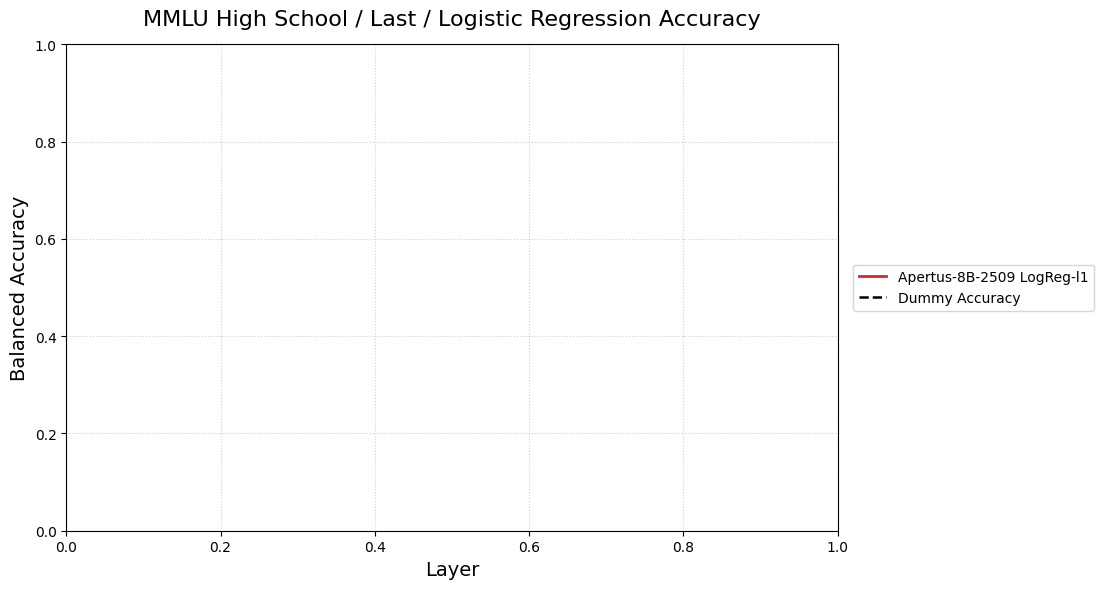

⚠️ Warning: Accuracy or Dummy-Accuracy not found in data


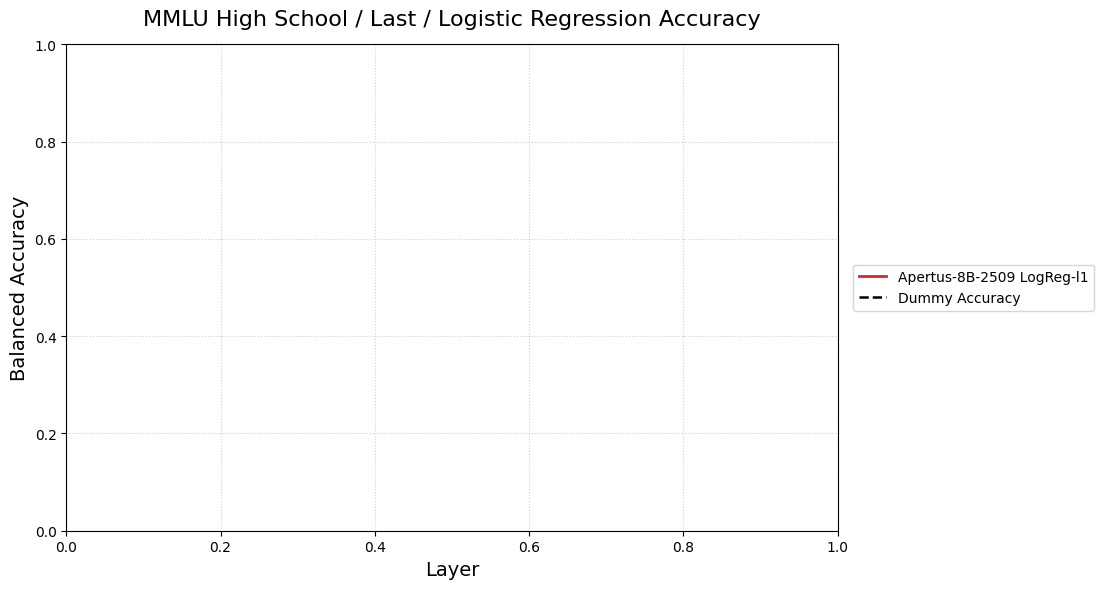

<Axes: title={'center': 'MMLU High School / Last / Logistic Regression Accuracy'}, xlabel='Layer', ylabel='Balanced Accuracy'>

In [ ]:
# Example: Plot accuracy for logistic regression
INDEX = 0
dataset_name = DATASET_NAMES[INDEX]
dataset_in_title = DATASET_TITLES[INDEX]
variant = "transform"
path = BASE_DIR + f"/mix/{dataset_name}/{MODEL_NAMES[2]}/df_probes_.pkl"
model = MODEL_NAMES[2]
results_by_llm = {model: load_pkl(path)}
result = results_by_llm[model]

# Plot accuracy for logistic regression
plot_accuracy_comparison_multi(
    results_by_llm,
    models_to_plot=["LogReg-l1"],
    token_positions=["exact"],
    title_suffix=f"{dataset_in_title} / Last / Logistic Regression Accuracy",
    accuracy_metric="Accuracy",  # Use "BACC" for balanced accuracy
)
plot_accuracy_comparison_multi(
    results_by_llm,
    models_to_plot=["LogReg-l1"],
    token_positions=["last"],
    title_suffix=f"{dataset_in_title} / Last / Logistic Regression Accuracy",
    accuracy_metric="Accuracy",  # Use "BACC" for balanced accuracy
)


⚠️ Warning: ACC or Dummy-ACC not found in data
⚠️ Warning: ACC or Dummy-ACC not found in data
⚠️ Warning: ACC or Dummy-ACC not found in data
⚠️ Warning: ACC or Dummy-ACC not found in data
⚠️ Warning: ACC or Dummy-ACC not found in data
⚠️ Warning: ACC or Dummy-ACC not found in data
⚠️ Warning: ACC or Dummy-ACC not found in data
⚠️ Warning: ACC or Dummy-ACC not found in data
⚠️ Warning: ACC or Dummy-ACC not found in data
⚠️ Warning: ACC or Dummy-ACC not found in data
⚠️ Warning: ACC or Dummy-ACC not found in data
⚠️ Warning: ACC or Dummy-ACC not found in data
⚠️ Warning: ACC or Dummy-ACC not found in data
⚠️ Warning: ACC or Dummy-ACC not found in data
⚠️ Warning: ACC or Dummy-ACC not found in data
⚠️ Warning: ACC or Dummy-ACC not found in data
⚠️ Warning: ACC or Dummy-ACC not found in data
⚠️ Warning: ACC or Dummy-ACC not found in data
⚠️ Warning: ACC or Dummy-ACC not found in data
⚠️ Warning: ACC or Dummy-ACC not found in data


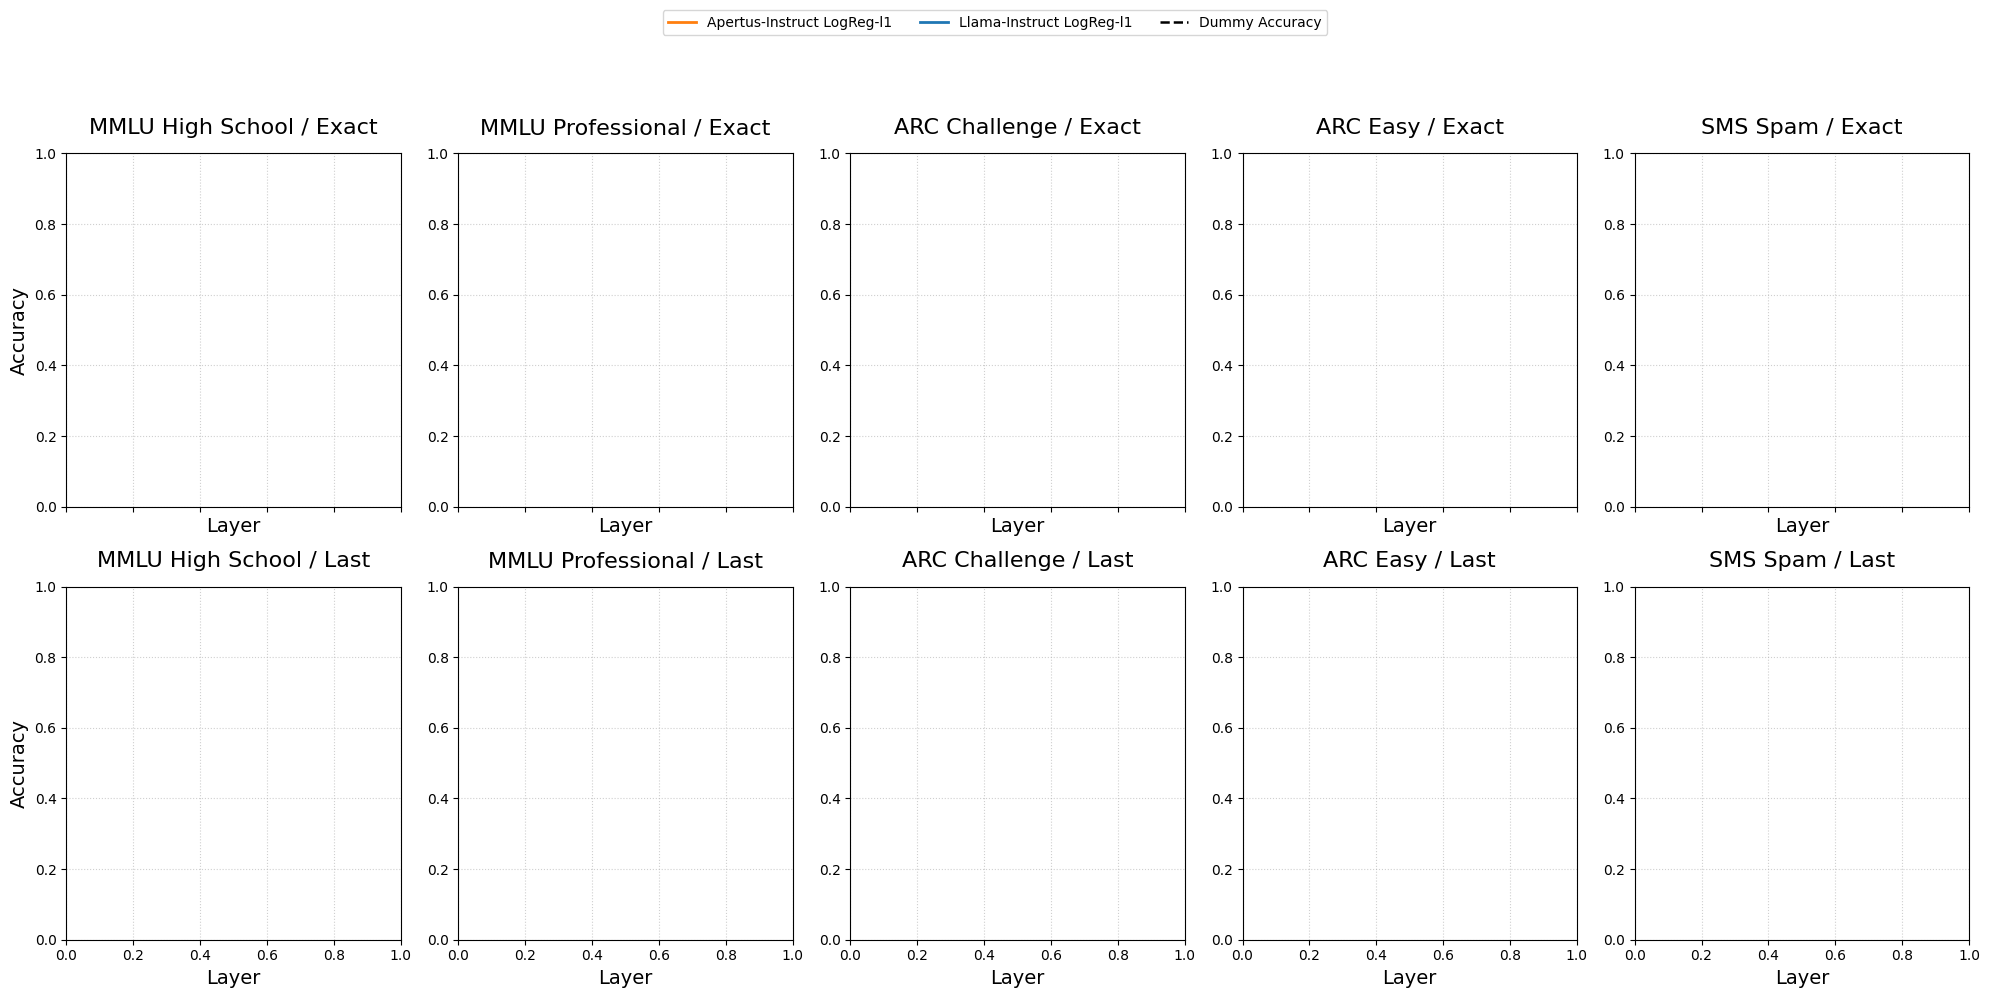

In [ ]:
# Plot accuracy for logistic regression across all datasets
INDICES = [0, 1, 2, 3, 4]                     # which datasets to use
models_to_plot = ["LogReg-l1"]                # logistic regression model
accuracy_metric = "ACC"                       # Use "ACC" or "BACC"

# 2 rows (Exact / Last) × N datasets
fig, axes = plt.subplots(
    2, len(INDICES),
    figsize=(20, 10),
    sharex="col",   # share x within each column
    # sharey="row"    # share y within each row
)

legend_handles, legend_labels = None, None

for col, idx in enumerate(INDICES):
    dataset_name = DATASET_NAMES[idx]
    dataset_title = DATASET_TITLES[idx]

    path1 = f"{BASE_DIR}/{dataset_name}/{MODEL_NAMES[0]}/df_probes_leave.pkl" 
    path2 = f"{BASE_DIR}/{dataset_name}/{MODEL_NAMES[1]}/df_probes_leave.pkl"
    # path1 = f"{BASE_DIR}/mix/{dataset_name}/{MODEL_NAMES[2]}/df_probes_.pkl" 
    # path2 = f"{BASE_DIR}/mix/{dataset_name}/{MODEL_NAMES[3]}/df_probes_logit.pkl"
    results_by_llm = {MODEL_NAMES[0]: load_pkl(path1), MODEL_NAMES[1]: load_pkl(path2)}
    result1 = results_by_llm[MODEL_NAMES[0]]
    # ---- Row 0: Exact token ----
    handles, labels = plot_accuracy_on_axis(
        axes[0, col],
        results_by_llm=results_by_llm,
        models_to_plot=models_to_plot,
        token_positions=["exact"],
        title_suffix=f"{dataset_title} / Exact",
        accuracy_metric=accuracy_metric,
        add_legend=False,
    )

    # ---- Row 1: Last token ----
    plot_accuracy_on_axis(
        axes[1, col],
        results_by_llm=results_by_llm,
        models_to_plot=models_to_plot,
        token_positions=["last"],
        title_suffix=f"{dataset_title} / Last",
        accuracy_metric=accuracy_metric,
        add_legend=False,
    )

    # grab legend info from first subplot only
    if legend_handles is None:
        legend_handles, legend_labels = handles, labels

# Only left column gets y-labels (optional, for cleanliness)
for row in range(2):
    for col in range(1, len(INDICES)):
        axes[row, col].set_ylabel("")

# One shared legend at the top
fig.legend(
    legend_handles,
    legend_labels,
    fontsize=10,
    loc="upper center",
    bbox_to_anchor=(0.5, 1),
    ncol=len(legend_labels),
    frameon=True,
)

fig.tight_layout(rect=[0, 0, 1, 0.9])
plt.show()


⚠️ Warning: Path does not exist: /iopsstor/scratch/cscs/astepancic/mera-runs/mix/ARC-Challenge+ARC-Easy+mmlu_high_school+mmlu_professional+sms_spam+sujet_finance_yesno_5k/Llama-3.1-8B-Instruct/df_probes_linear_intercept.pkl
⚠️ Warning: Path does not exist: /iopsstor/scratch/cscs/astepancic/mera-runs/mix/mmlu_high_school+mmlu_professional+ARC-Challenge+ARC-Easy/Llama-3.1-8B-Instruct/df_probes_linear_intercept.pkl
⚠️ Warning: Path does not exist: /iopsstor/scratch/cscs/astepancic/mera-runs/mix/ARC-Easy+sms_spam/Llama-3.1-8B-Instruct/df_probes_linear_intercept.pkl
⚠️ Warning: Path does not exist: /iopsstor/scratch/cscs/astepancic/mera-runs/mix/mmlu_high_school+mmlu_professional/Llama-3.1-8B-Instruct/df_probes_linear_intercept.pkl
⚠️ Warning: Path does not exist: /iopsstor/scratch/cscs/astepancic/mera-runs/mix/sms_spam+sujet_finance_yesno_5k/Llama-3.1-8B-Instruct/df_probes_linear_intercept.pkl
⚠️ Warning: Path does not exist: /iopsstor/scratch/cscs/astepancic/mera-runs/mix/mmlu_high_school

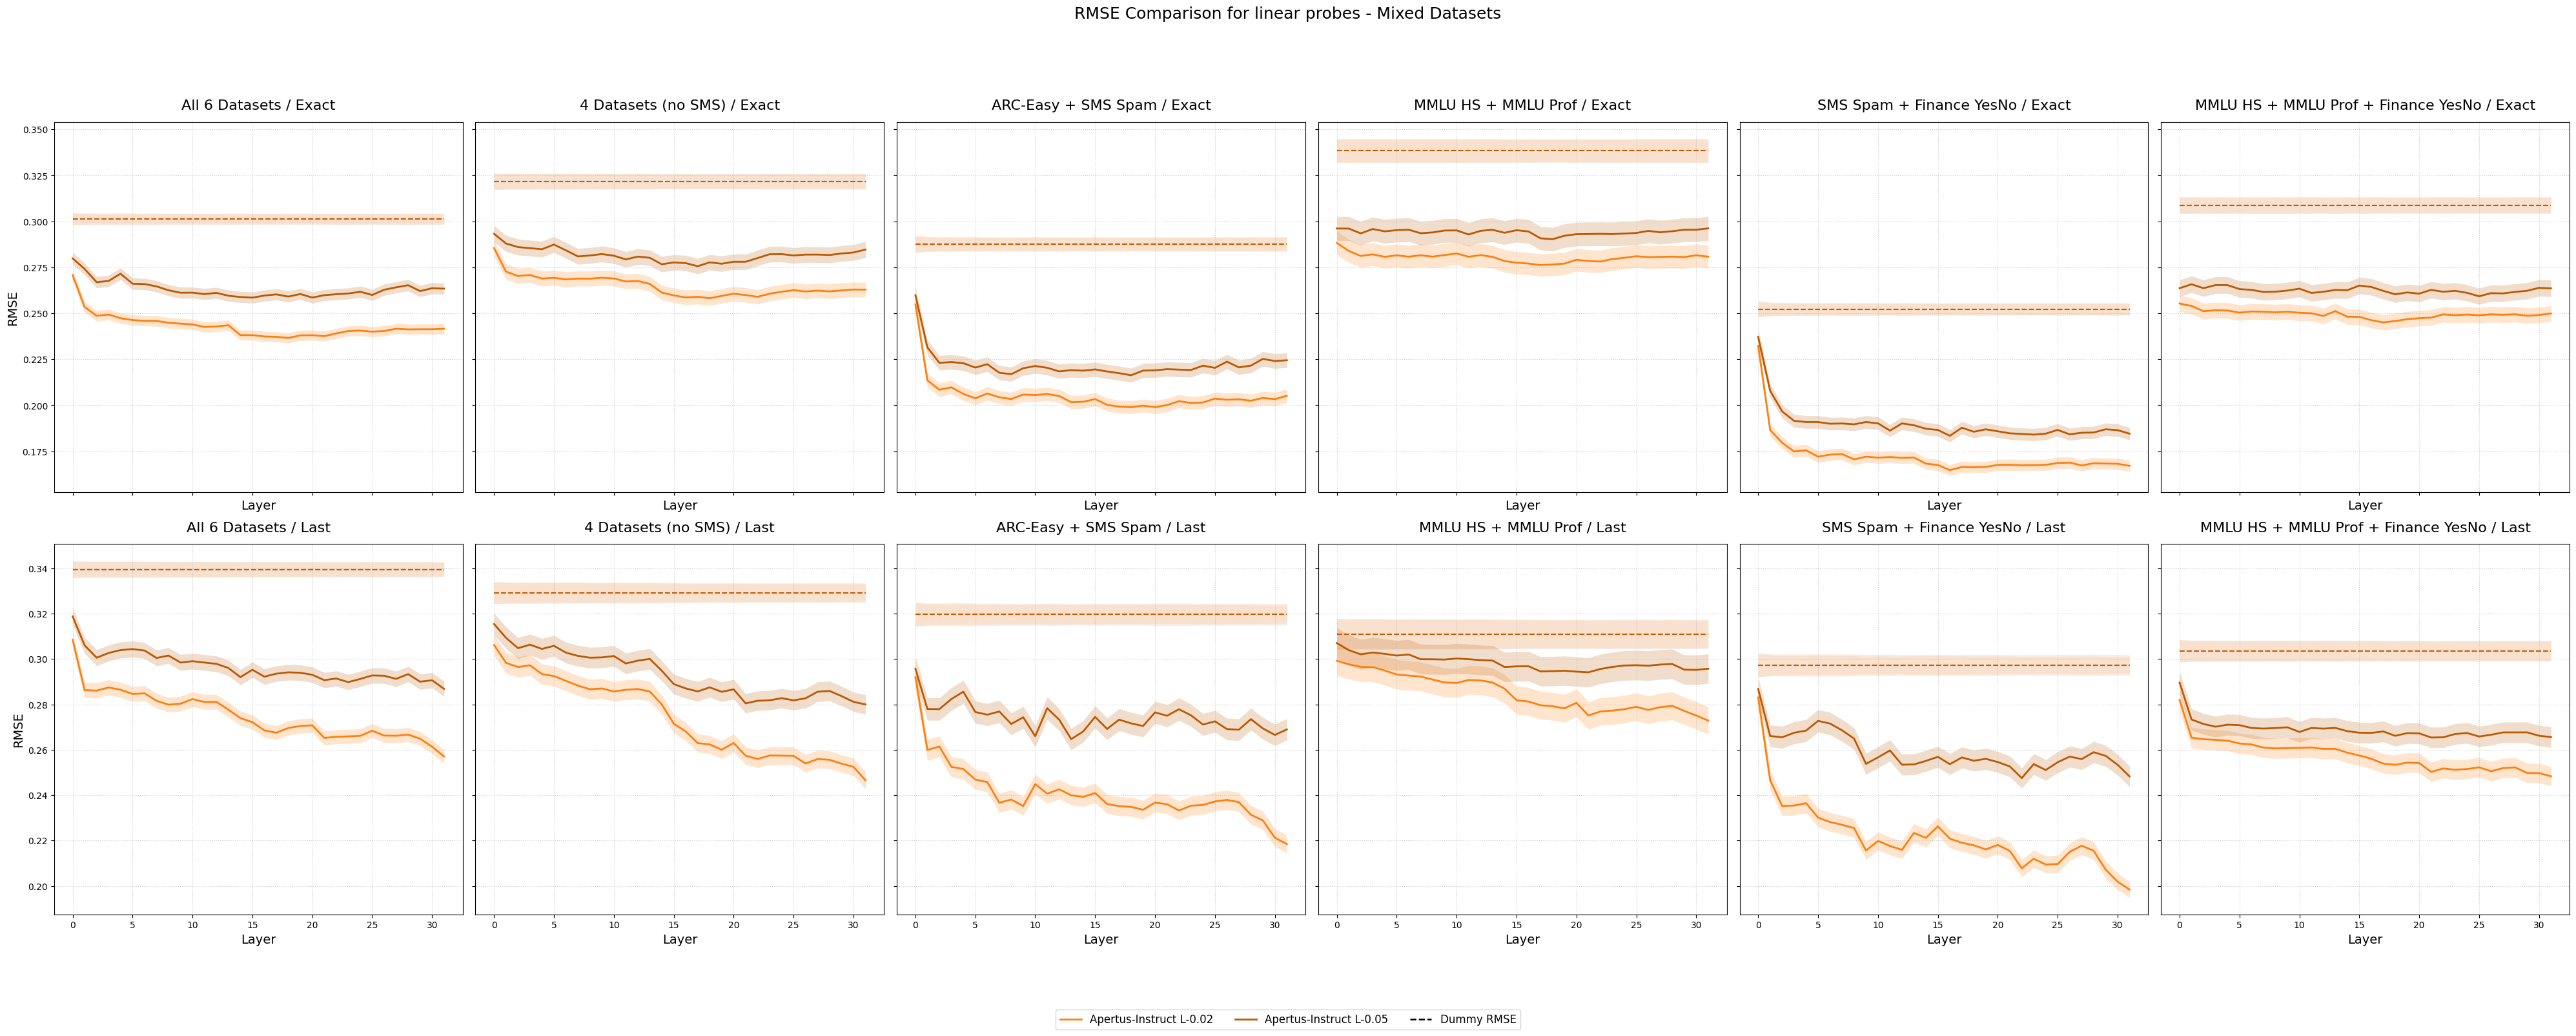

Plotted 6 mixed dataset combinations


In [ ]:
# Plot mixed datasets from train_probes_all.sh lines 54-57
# Line 54: ARC-Challenge ARC-Easy mmlu_high_school mmlu_professional sms_spam
# Line 57: mmlu_high_school mmlu_professional ARC-Challenge ARC-Easy

# Define the mixed dataset combinations
mixed_datasets = [
    {
        "name": "ARC-Challenge+ARC-Easy+mmlu_high_school+mmlu_professional+sms_spam+sujet_finance_yesno_5k",
        "title": "All 6 Datasets",
        "datasets": ["ARC-Challenge", "ARC-Easy", "mmlu_high_school", "mmlu_professional", "sms_spam", "sujet_finance_yesno_5k"]
    },
    {
        "name": "mmlu_high_school+mmlu_professional+ARC-Challenge+ARC-Easy",
        "title": "4 Datasets (no SMS)",
        "datasets": ["mmlu_high_school", "mmlu_professional", "ARC-Challenge", "ARC-Easy"]
    },
    {
        "name": "ARC-Easy+sms_spam",
        "title": "ARC-Easy + SMS Spam",
        "datasets": ["ARC-Easy", "sms_spam"]
    },
    {
        "name": "mmlu_high_school+mmlu_professional",
        "title": "MMLU HS + MMLU Prof",
        "datasets": ["mmlu_high_school", "mmlu_professional"]
    },
    {
        "name": "sms_spam+sujet_finance_yesno_5k",
        "title": "SMS Spam + Finance YesNo",
        "datasets": ["sms_spam", "sujet_finance_yesno_5k"]
    },
    {
        "name": "mmlu_high_school+mmlu_professional+sujet_finance_yesno_5k",
        "title": "MMLU HS + MMLU Prof + Finance YesNo",
        "datasets": ["mmlu_high_school", "mmlu_professional", "sujet_finance_yesno_5k"]
    }
]

# Configuration
model_indices = [0, 1]  # Apertus-8B-Instruct-2509, Llama-3.1-8B-Instruct
probe_type = "linear"
file_suffix = "_intercept"
models_to_plot = ["L-0.02", "L-0.05"]
subdir = "mix"

# Convert model indices to model names
model_names = []
for idx in model_indices:
    if isinstance(idx, int):
        model_names.append(MODEL_NAMES[idx])
    else:
        model_names.append(idx)

# Create figure: 2 rows (Exact / Last) × N mixed datasets
fig, axes = plt.subplots(
    2, len(mixed_datasets),
    figsize=(40, 15),
    sharex="col",
    sharey="row"
)

# Handle single dataset case
if len(mixed_datasets) == 1:
    axes = axes.reshape(2, 1)

legend_handles, legend_labels = None, None

for col, mix_info in enumerate(mixed_datasets):
    mixed_name = mix_info["name"]
    mixed_title = mix_info["title"]
    
    # Load data for all models
    results_by_llm = {}
    for model_name in model_names:
        path = f"{BASE_DIR}/{subdir}/{mixed_name}/{model_name}/df_probes_{probe_type}{file_suffix}.pkl"
        if os.path.exists(path):
            results_by_llm[model_name] = load_pkl(path)
        else:
            print(f"⚠️ Warning: Path does not exist: {path}")
    
    if not results_by_llm:
        print(f"⚠️ Warning: No data loaded for mixed dataset {mixed_name}")
        continue
    
    # ---- Row 0: Exact token ----
    handles, labels = plot_rmse_on_axis(
        axes[0, col],
        results_by_llm=results_by_llm,
        models_to_plot=models_to_plot,
        token_positions=["exact"],
        title_suffix=f"{mixed_title} / Exact",
        add_legend=False,
    )
    
    # ---- Row 1: Last token ----
    plot_rmse_on_axis(
        axes[1, col],
        results_by_llm=results_by_llm,
        models_to_plot=models_to_plot,
        token_positions=["last"],
        title_suffix=f"{mixed_title} / Last",
        add_legend=False,
    )
    
    # Grab legend info from first subplot only
    if legend_handles is None:
        legend_handles, legend_labels = handles, labels

# Only left column gets y-labels
for row in range(2):
    for col in range(1, len(mixed_datasets)):
        axes[row, col].set_ylabel("")

# One shared legend at the bottom
if legend_handles is not None:
    fig.legend(
        legend_handles,
        legend_labels,
        fontsize=12,
        loc="upper center",
        bbox_to_anchor=(0.5, -0.05),
        ncol=len(legend_labels),
        frameon=True,
    )

fig.suptitle(f"RMSE Comparison for {probe_type} probes - Mixed Datasets", fontsize=18)
fig.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()

print(f"Plotted {len(mixed_datasets)} mixed dataset combinations")


Creating figure for EXACT token...


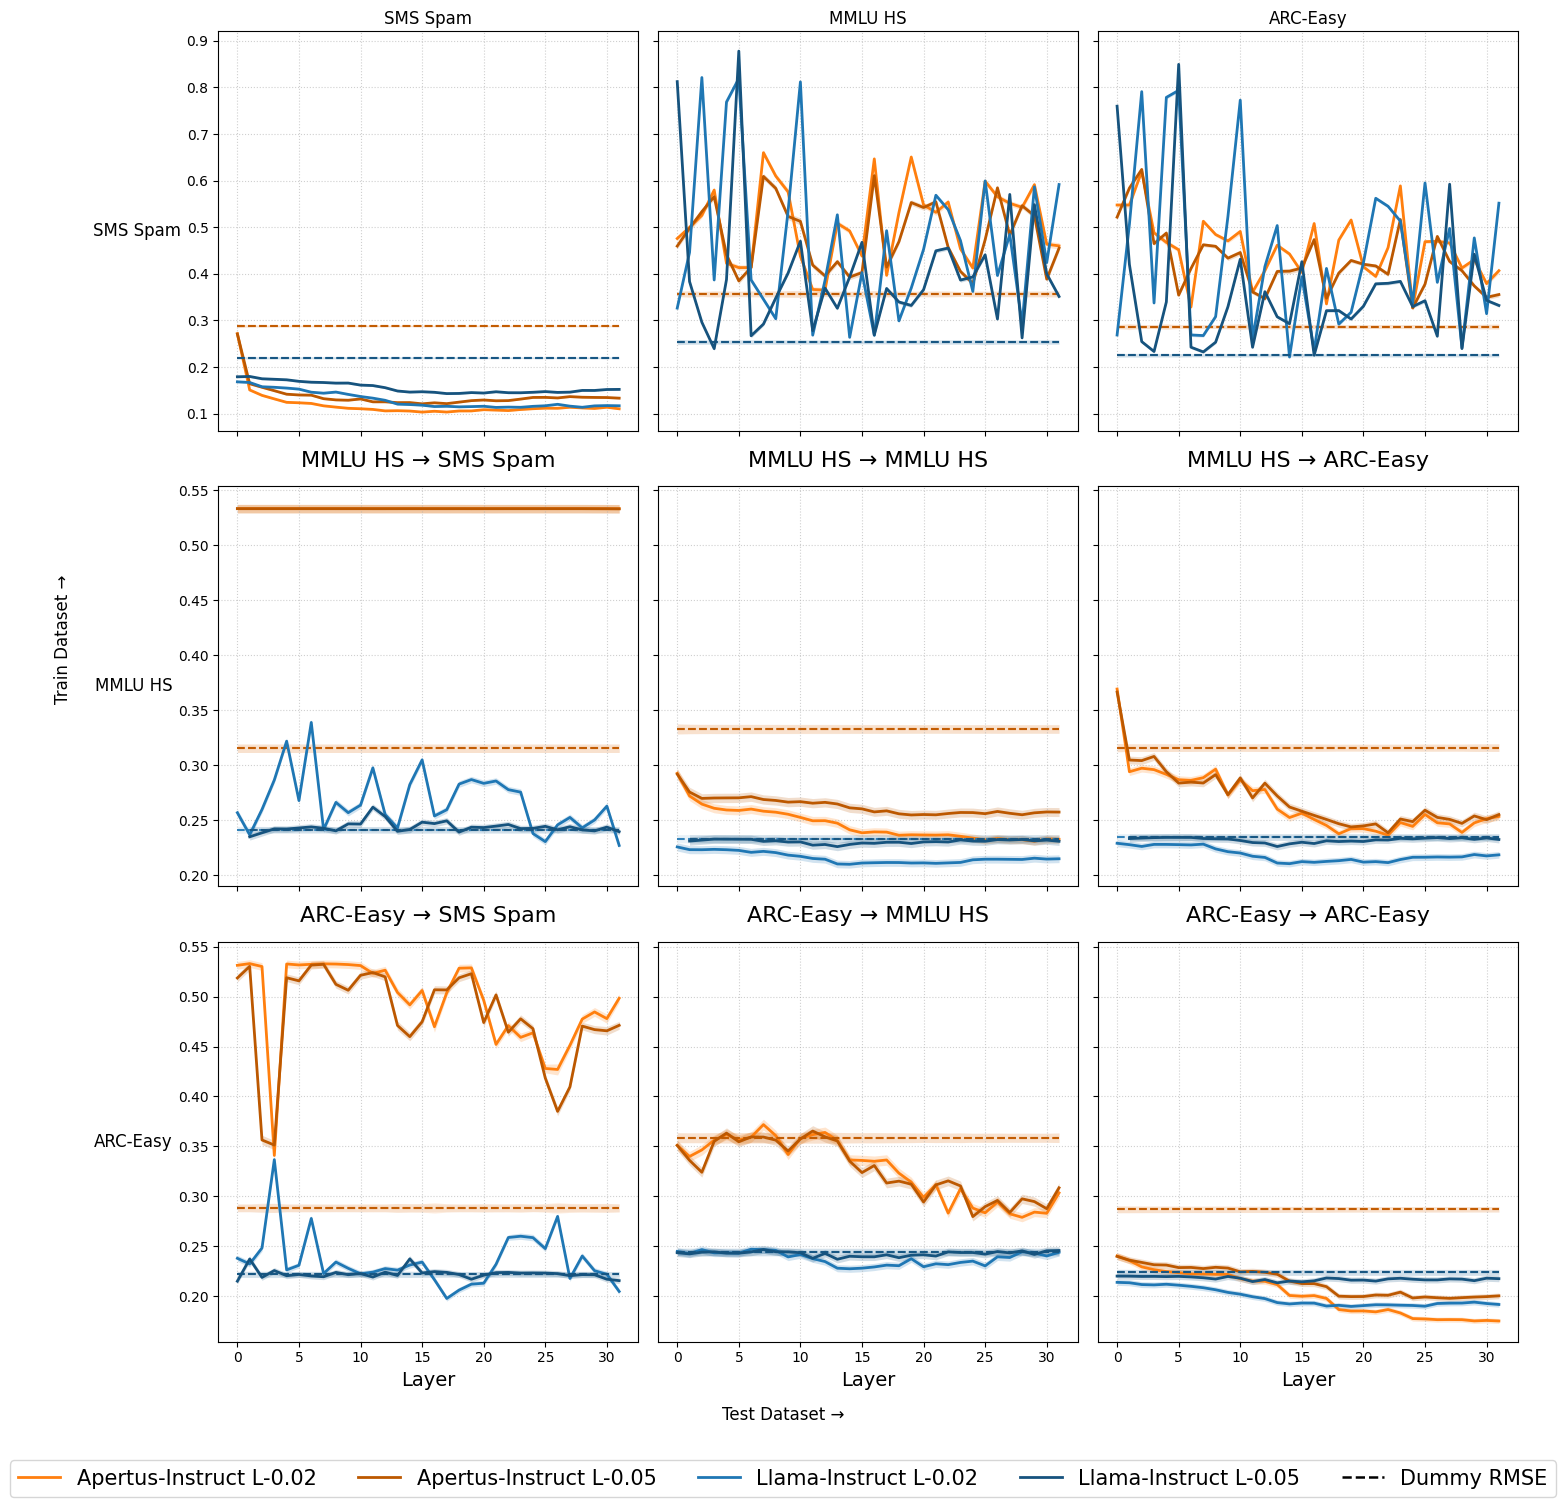

Creating figure for LAST token...


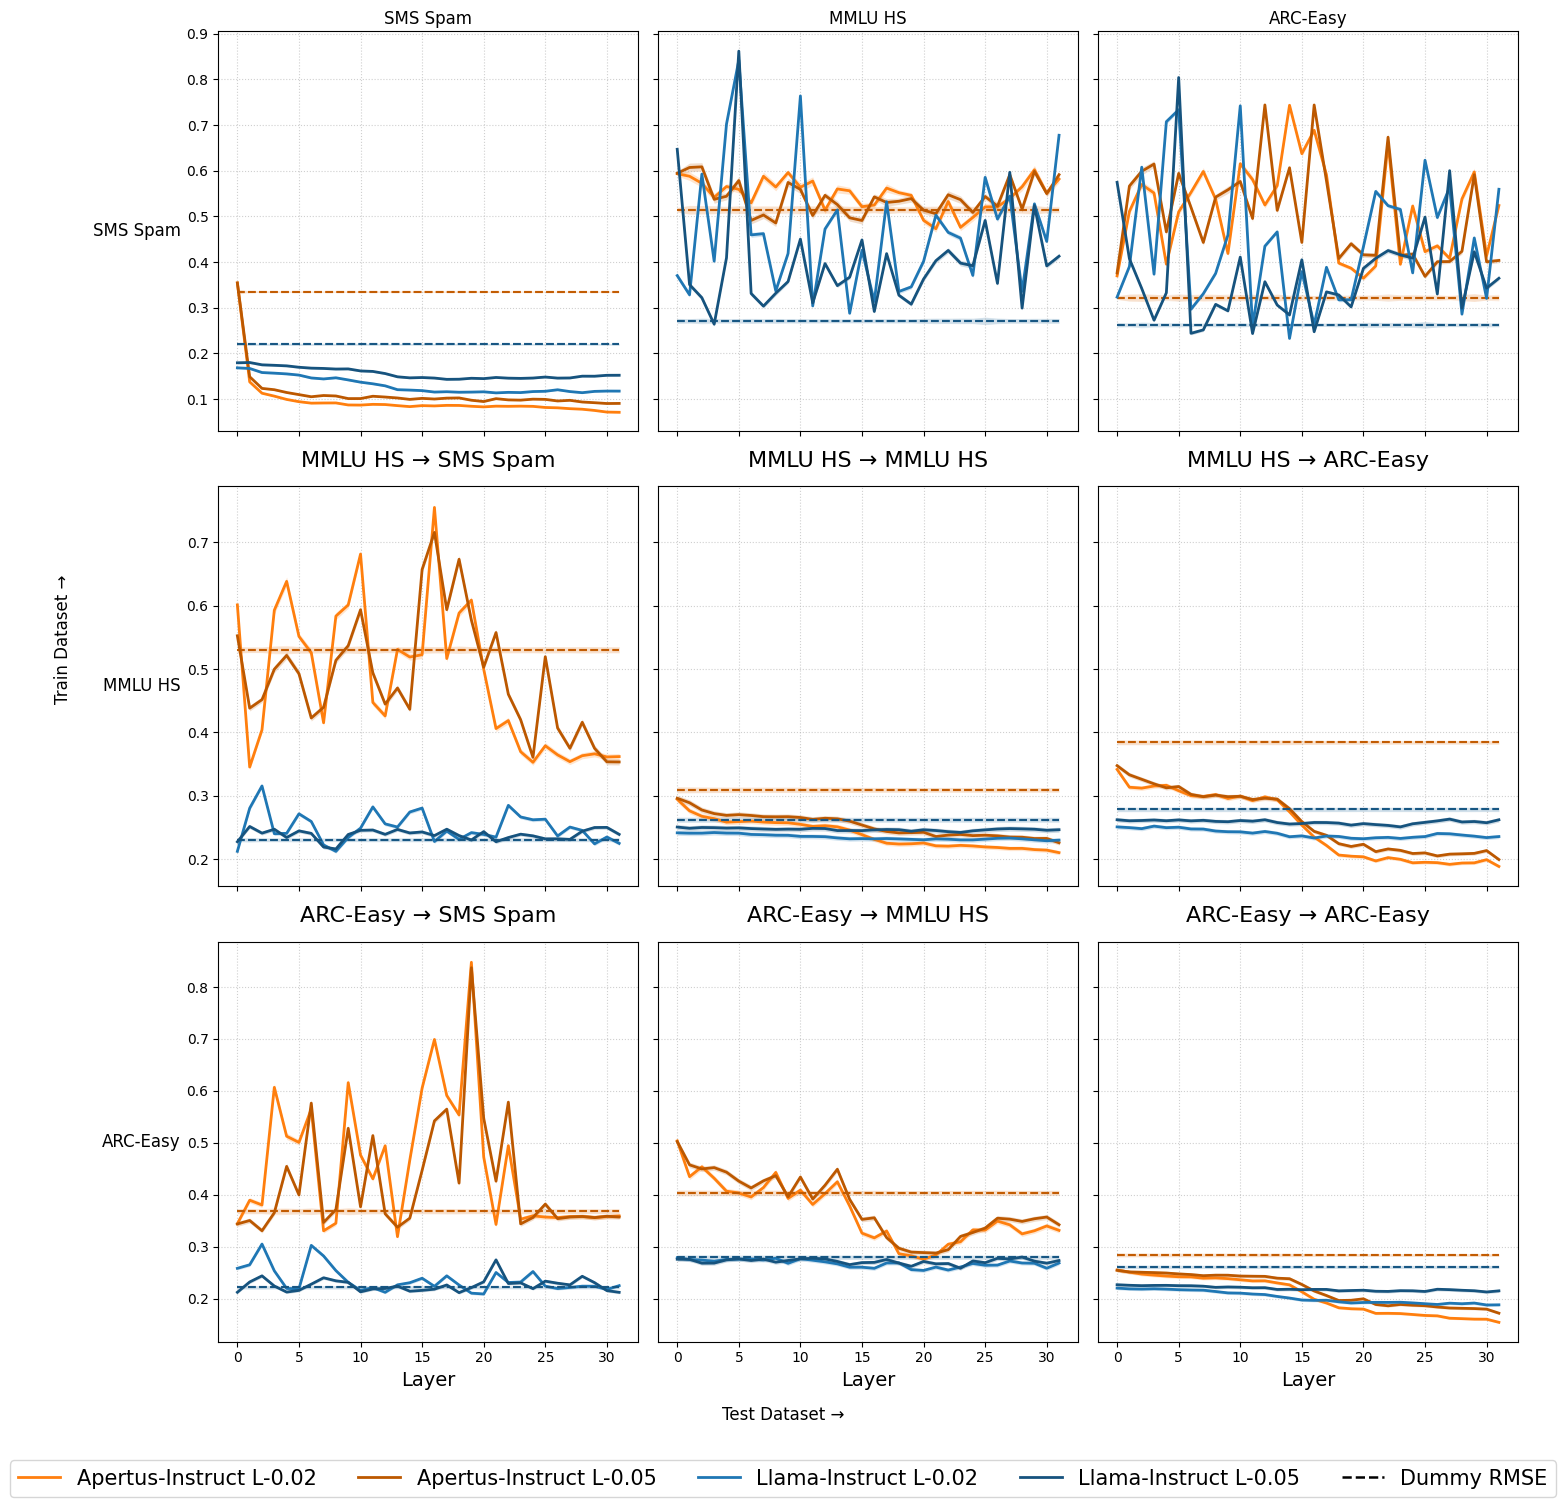

Plotted all 3×3 = 9 cross-dataset combinations


In [10]:
# Plot cross-dataset probes
# Cross-dataset probes train on one dataset and test on another
# Creates two figures: one for exact token, one for last token
# Each figure is a 5x5 grid showing all train→test dataset combinations

# All datasets
# datasets = ["sms_spam", "sujet_finance_yesno_5k", "mmlu_high_school", "mmlu_professional", "ARC-Easy", "ARC-Challenge"]
# dataset_titles = ["SMS Spam", "Finance YesNo", "MMLU HS", "MMLU Prof", "ARC-Easy", "ARC-Chall"]
datasets = ["sms_spam", "mmlu_high_school", "ARC-Easy"]
dataset_titles = ["SMS Spam", "MMLU HS", "ARC-Easy"]

# Configuration
model_indices = [0, 1]  # Apertus-8B-Instruct-2509, Llama-3.1-8B-Instruct
save_name = None  # None or "" to use default pattern: {train_dataset}_to_{test_dataset}
                  # Or specify a custom suffix like "linear_intercept"
models_to_plot = ["L-0.02", "L-0.05"]
subdir = "cross_dataset"

# Convert model indices to model names
model_names = []
for idx in model_indices:
    if isinstance(idx, int):
        model_names.append(MODEL_NAMES[idx])
    else:
        model_names.append(idx)

# Function to create one figure for a specific token position
def create_cross_dataset_figure(token_pos: str):
    """Create a NxN grid figure for cross-dataset probes."""
    n_datasets = len(datasets)
    fig, axes = plt.subplots(
        n_datasets, n_datasets,
        figsize=(5 * n_datasets, 5 * n_datasets),
        sharex="col",
        sharey="row"
    )
    
    legend_handles, legend_labels = None, None
    
    for row, train_ds in enumerate(datasets):
        for col, test_ds in enumerate(datasets):
            ax = axes[row, col]
            
            # Determine file name
            if save_name is not None and save_name != "":
                filename = f"df_probes_{save_name}.pkl"
            else:
                filename = f"df_probes_{train_ds}_to_{test_ds}.pkl"
            
            # Load data for all models
            results_by_llm = {}
            for model_name in model_names:
                path = f"{BASE_DIR}/{subdir}/{train_ds}_to_{test_ds}/{model_name}/{filename}"
                if os.path.exists(path):
                    results_by_llm[model_name] = load_pkl(path)
                else:
                    # Only print warning for first model to avoid spam
                    if model_name == model_names[0]:
                        print(f"⚠️ Warning: Path does not exist: {path}")
            
            if not results_by_llm:
                # Still create empty plot with title
                ax.set_title(f"{dataset_titles[datasets.index(train_ds)]} → {dataset_titles[datasets.index(test_ds)]}", 
                           fontsize=10)
                ax.text(0.5, 0.5, "No data", ha="center", va="center", transform=ax.transAxes)
                continue
            
            # Plot on this axis
            handles, labels = plot_rmse_on_axis(
                ax,
                results_by_llm=results_by_llm,
                models_to_plot=models_to_plot,
                token_positions=[token_pos],
                title_suffix=f"{dataset_titles[datasets.index(train_ds)]} → {dataset_titles[datasets.index(test_ds)]}",
                add_legend=False,
            )
            
            # Grab legend info from first subplot only
            if legend_handles is None:
                legend_handles, legend_labels = handles, labels
    
    # Only left column and bottom row get labels
    for row in range(n_datasets):
        for col in range(n_datasets):
            if col > 0:
                axes[row, col].set_ylabel("")
            if row < n_datasets - 1:
                axes[row, col].set_xlabel("")
    
    # Add row labels (train datasets) on the left
    for row, train_ds in enumerate(datasets):
        axes[row, 0].set_ylabel(dataset_titles[row], fontsize=12, rotation=0, ha="right", va="center")
    
    # Add column labels (test datasets) on the top
    for col, test_ds in enumerate(datasets):
        axes[0, col].set_title(dataset_titles[col], fontsize=12, pad=5)
    
    # One shared legend at the bottom
    if legend_handles is not None:
        fig.legend(
            legend_handles,
            legend_labels,
            fontsize=15,
            loc="upper center",
            bbox_to_anchor=(0.5, 0),
            ncol=len(legend_labels),
            frameon=True,
        )
    
    # fig.suptitle(f"Cross-Dataset Probes - {token_pos.capitalize()} Token", fontsize=16, y=0.995)
    fig.text(0.5, 0.02, "Test Dataset →", ha="center", fontsize=12)
    fig.text(0.02, 0.5, "Train Dataset →", ha="center", fontsize=12, rotation=90)
    fig.tight_layout(rect=[0.03, 0.03, 1, 0.97])
    plt.show()
    
    return fig, axes

# Create figure for exact token
print("Creating figure for EXACT token...")
create_cross_dataset_figure("exact")

# Create figure for last token
print("Creating figure for LAST token...")
create_cross_dataset_figure("last")

print(f"Plotted all {len(datasets)}×{len(datasets)} = {len(datasets)**2} cross-dataset combinations")
